# 06 — NMPCの最適制御問題と重み

## 目的
OCS2 SQP-NMPCの役割を、解ける小さな有限ホライズン問題へ縮約して体験する。
実装の24/24問題そのものをPythonで再実装する章ではない。

実装対応:
- `LeggedInterface::setupOptimalControlProblem()`
- `LeggedRobotQuadraticTrackingCost`
- `LeggedController::setupMpc()` の `SqpMpc`


## 検証範囲に関する必須注記

このprojectでは **ROS2 portを作成・compile・実行していない**。したがってROS2 parityは
**NOT VERIFIED / FAIL-CLOSED** である。上流commit `a7f381c0367e98e31c01336e678eef47e304d40d` はROS1実装であり、
project所有MuJoCo adapterはOCS2のhorizon SQPを瞬時force plannerへ、
Pinocchio/qpOASES WBCをMuJoCo acceleration inverse dynamicsへ置換し、
元のestimator/hardware経路も持たない。保存済み30 scenario dataが示すのはadapter挙動だけで、
上流 `legged_control` の性能でもROS2移行の検証でもない。


In [1]:
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`from pathlib import Path` の依存を明示して再現可能な実行環境を作る。
from pathlib import Path
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`import numpy as np` の依存を明示して再現可能な実行環境を作る。
import numpy as np
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`import matplotlib.pyplot as plt` の依存を明示して再現可能な実行環境を作る。
import matplotlib.pyplot as plt

# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = Path.cwd()` の演算・変換をPythonで評価する。
ROOT = Path.cwd()
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`for candidate in [ROOT, *ROOT.parents]:` の反復範囲を固定して各sampleを処理する。 数式: `for candidate in [ROOT, *ROOT.parents]:` の演算・変換をPythonで評価する。
for candidate in [ROOT, *ROOT.parents]:
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`if (candidate / "pyproject.toml").exists():` の条件で安全側の実行分岐を選ぶ。 数式: `if (candidate / "pyproject.toml").exists():` の演算・変換をPythonで評価する。
    if (candidate / "pyproject.toml").exists():
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = candidate` の演算・変換をPythonで評価する。
        ROOT = candidate
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`break` をこの章の処理順に沿って実行する。
        break

# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`np.set_printoptions(precision` を後続計算で使う明示的な中間量として設定する。 数式: `np.set_printoptions(precision=4, suppress=True)` の演算・変換をPythonで評価する。
np.set_printoptions(precision=4, suppress=True)
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})` の要素または終端を対応付ける。
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`print("repository:", ROOT)` の観測値を表示して判定根拠を残す。
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


\[
\min_{u(\cdot)}\phi(x(T))+\int_0^T
\|x-x^\mathrm{ref}\|_Q^2+\|u-u^\mathrm{wc}\|_R^2\,dt
\]
subject to centroidal dynamics、接触等式、摩擦・自己衝突制約。

実装値: horizon 1.0 s、shooting dt 0.015 s、SQP iteration 1。
入力参照はゼロ力ではなく、接地脚へ体重を配る `weightCompensatingInput`。


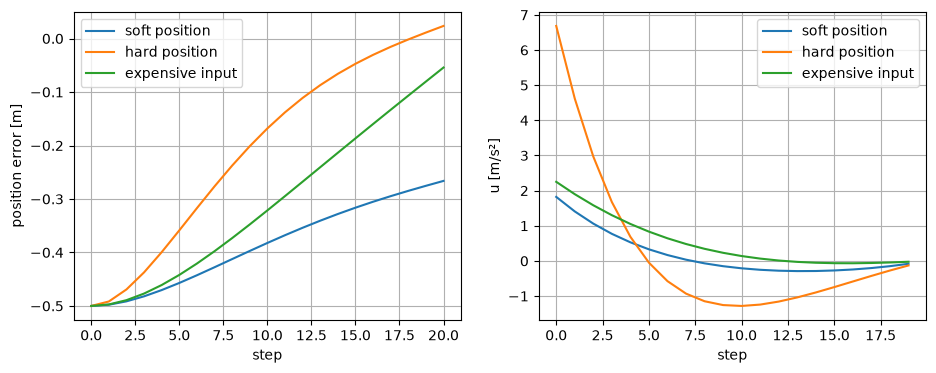

In [2]:
# 1D double integratorで「位置/速度追従 vs 力の節約」を見る。
# x=[position, velocity], u=acceleration。有限ホライズンLQRを後退Riccatiで解く。
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`finite_horizon_lqr` の責務を独立関数として定義する。 数式: `def finite_horizon_lqr(q_pos=20.0, q_vel=2.0, r_u=0.2, dt=0.05, N=20):` の演算・変換をPythonで評価する。
def finite_horizon_lqr(q_pos=20.0, q_vel=2.0, r_u=0.2, dt=0.05, N=20):
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`A` を後続計算で使う明示的な中間量として設定する。 数式: `A = np.array([[1, dt], [0, 1]])` の演算・変換をPythonで評価する。
    A = np.array([[1, dt], [0, 1]])
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`B` を後続計算で使う明示的な中間量として設定する。 数式: `B = np.array([[0.5*dt**2], [dt]])` の演算・変換をPythonで評価する。
    B = np.array([[0.5*dt**2], [dt]])
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`Q` を後続計算で使う明示的な中間量として設定する。 数式: `Q = np.diag([q_pos, q_vel])` の演算・変換をPythonで評価する。
    Q = np.diag([q_pos, q_vel])
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`R` を後続計算で使う明示的な中間量として設定する。 数式: `R = np.array([[r_u]])` の演算・変換をPythonで評価する。
    R = np.array([[r_u]])
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`P` を後続計算で使う明示的な中間量として設定する。 数式: `P = Q.copy()` の演算・変換をPythonで評価する。
    P = Q.copy()
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`gains` を後続計算で使う明示的な中間量として設定する。 数式: `gains = []` の演算・変換をPythonで評価する。
    gains = []
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`for _ in range(N):` の反復範囲を固定して各sampleを処理する。
    for _ in range(N):
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`K` を後続計算で使う明示的な中間量として設定する。 数式: `K = np.linalg.solve(R + B.T@P@B, B.T@P@A)` の演算・変換をPythonで評価する。
        K = np.linalg.solve(R + B.T@P@B, B.T@P@A)
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `gains.append(K)` の要素または終端を対応付ける。
        gains.append(K)
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`P` を後続計算で使う明示的な中間量として設定する。 数式: `P = Q + A.T@P@(A-B@K)` の演算・変換をPythonで評価する。
        P = Q + A.T@P@(A-B@K)
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `gains.reverse()` の要素または終端を対応付ける。
    gains.reverse()
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`x` を後続計算で使う明示的な中間量として設定する。 数式: `x = np.array([-0.5, 0.0])` の演算・変換をPythonで評価する。
    x = np.array([-0.5, 0.0])
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`xs, us` を後続計算で使う明示的な中間量として設定する。 数式: `xs, us = [x.copy()], []` の演算・変換をPythonで評価する。
    xs, us = [x.copy()], []
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`for K in gains:` の反復範囲を固定して各sampleを処理する。
    for K in gains:
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`u` を後続計算で使う明示的な中間量として設定する。 数式: `u = float((-K @ x).item())` の演算・変換をPythonで評価する。
        u = float((-K @ x).item())
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`x` を後続計算で使う明示的な中間量として設定する。 数式: `x = A@x + B[:,0]*u` の演算・変換をPythonで評価する。
        x = A@x + B[:,0]*u
        # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `xs.append(x.copy()); us.append(u)` の要素または終端を対応付ける。
        xs.append(x.copy()); us.append(u)
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`return np.asarray(xs), np.asarray(us)` の値を次の制御境界へ返す。 数式: `return np.asarray(xs), np.asarray(us)` の演算・変換をPythonで評価する。
    return np.asarray(xs), np.asarray(us)

# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`configs` を後続計算で使う明示的な中間量として設定する。 数式: `configs = [(5, 0.2, "soft position"), (50, 0.2, "hard position"), (50, 2…` の演算・変換をPythonで評価する。
configs = [(5, 0.2, "soft position"), (50, 0.2, "hard position"), (50, 2.0, "expensive input")]
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`fig, axes` を後続計算で使う明示的な中間量として設定する。 数式: `fig, axes = plt.subplots(1, 2, figsize=(11,4))` の演算・変換をPythonで評価する。
fig, axes = plt.subplots(1, 2, figsize=(11,4))
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`for q, r, label in configs:` の反復範囲を固定して各sampleを処理する。
for q, r, label in configs:
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`xs, us` を後続計算で使う明示的な中間量として設定する。 数式: `xs, us = finite_horizon_lqr(q_pos=q, r_u=r)` の演算・変換をPythonで評価する。
    xs, us = finite_horizon_lqr(q_pos=q, r_u=r)
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`axes[0].plot(xs[:,0], label` を後続計算で使う明示的な中間量として設定する。 数式: `axes[0].plot(xs[:,0], label=label)` の演算・変換をPythonで評価する。
    axes[0].plot(xs[:,0], label=label)
    # 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`axes[1].plot(us, label` を後続計算で使う明示的な中間量として設定する。 数式: `axes[1].plot(us, label=label)` の演算・変換をPythonで評価する。
    axes[1].plot(us, label=label)
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `axes[0].set_ylabel("position error [m]"); axes[1].set_ylabel("u [m/s²]")` の要素または終端を対応付ける。 数式: `axes[0].set_ylabel("position error [m]"); axes[1].set_ylabel("u [m/s²]")` の演算・変換をPythonで評価する。
axes[0].set_ylabel("position error [m]"); axes[1].set_ylabel("u [m/s²]")
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、`for ax in axes: ax.set_xlabel("step"); ax.legend()` の反復範囲を固定して各sampleを処理する。
for ax in axes: ax.set_xlabel("step"); ax.legend()
# 背景: 有限horizonでは追従と入力費用を同時に評価する。目的: 縮約OCPでQ/R変更の因果を確認するため、直前の式・構造へ `plt.show()` の要素または終端を対応付ける。
plt.show()


## 実装のQ/Rを読む
A1で大きい状態重みは水平位置1000、高さ1500、yaw 100、roll/pitch 300。
入力R後半は設定ファイル上「足速度」だが、名目姿勢のJacobianで
\(R_{v_j}=J_b^	op R_\mathrm{task}J_b\) と関節速度blockへ写される。

### チューニングの因果
- Qを上げる: 誤差を早く戻すが、GRF・関節速度・制約余裕を使う。
- Rを上げる: 入力は滑らか/小さくなるが、追従が遅れる。
- horizonを伸ばす: 先を見るが、計算量とモデル誤差の影響が増える。
- SQP反復を増やす: 収束改善の可能性と締切超過を同時に評価する。

一度に1群だけ変更し、solver time、KKT/constraint violation、姿勢誤差、
torque saturation、slipを同じrunで記録する。


## 章固有の背景
                良い瞬間入力だけでは接地切替後を準備できないため、有限horizonで状態・入力列を同時評価する。

                ## 章固有の目的
                OCPのcost、dynamics、constraint、SQP設定をsetup symbolへ対応付け、Q/R変更の因果を読めるようにする。

                ## この章のASCIIデータフロー
                ```text
                x0 + target + ModeSchedule -> setupOptimalControlProblem
 -> cost(Q,R)+dynamics+constraints -> SqpMpc(horizon 1 s)
 -> policy {x*(t),u*(t),mode(t)}
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_interface/src/LeggedInterface.cpp
problem.dynamicsPtr = LeggedRobotDynamicsAD(...);         // xdot=f(x,u)
problem.costPtr->add("quadraticTracking", trackingCost);   // ||x-xr||_Q^2+||u-uwc||_R^2
problem.equalityConstraintPtr->add(...);                   // contact-mode等式
problem.inequalityConstraintPtr->add(...);                 // friction/collision
// external/legged_control/legged_controllers/src/LeggedController.cpp
mpcPtr_.reset(new SqpMpc(mpcSettings,sqpSettings,problem)); // receding-horizon SQP
// adapter limitation: src/legged_control_mujoco はSqpMpcを呼ばない
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                Q/Rは単なるgainではなく、制約下で有限な資源をどの誤差へ配るかを決める。adapterの瞬時plannerはこのSQP horizonを持たない。
